# Class item count

Counts YOLOseg instances per class for **any** label folder you pick.

- Each non-empty line in a `.txt` label file = one instance. First token = class id (0-based).
- Class names come from a class-names `.txt` file: line 1 = class id 0, ...

**How to use:** run the cells top to bottom. Cell&nbsp;1 opens **two pickers** — first choose the labels folder, then choose the class-names `.txt` file.

## 1. Pick inputs  —  labels folder + class .txt

In [ ]:
from pathlib import Path
from collections import Counter
import pandas as pd
import tkinter as tk
from tkinter import filedialog

_root = tk.Tk(); _root.withdraw(); _root.attributes('-topmost', True)

# 1) folder of .txt labels
LABEL_DIR = Path(filedialog.askdirectory(title='1/2  Select LABELS folder (.txt files)'))
assert LABEL_DIR.is_dir(), 'No labels folder selected'

# 2) class-names .txt (start browsing near the labels folder)
CLASS_FILE = Path(filedialog.askopenfilename(
    title='2/2  Select CLASS-NAMES .txt file',
    initialdir=LABEL_DIR.parent,
    filetypes=[('Text files', '*.txt'), ('All files', '*.*')]))
assert CLASS_FILE.is_file(), 'No class-names file selected'

_root.destroy()

# Results ALWAYS live in a 'results' folder next to THIS notebook (not next to the
# labels), grouped into results/<source-folder-name>/ so you know the origin.
NOTEBOOK_DIR = Path.cwd()
RESULTS_DIR = NOTEBOOK_DIR / 'results' / LABEL_DIR.name
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('notebook  :', NOTEBOOK_DIR)
print('labels    :', LABEL_DIR)
print('class file:', CLASS_FILE)
print('results   :', RESULTS_DIR)

### 1b. Auto-tidy stray outputs

Sweeps any leftover `<base>_<source>.csv/png` files in the notebook folder (from older runs) into `results/<source>/`. Runs every time, so strays never pile up.

In [ ]:
# Auto-tidy: older runs saved results loose as '<base>_<source>.csv/png'. Sweep any
# such strays in the notebook folder into results/<source>/ with a plain name, so old
# + new outputs always land in the same tidy structure.
BASENAMES = ['class_counts', 'perday_counts', 'perday_raw', 'perday_rate', 'forecast', 'stability']
moved = 0
for f in list(NOTEBOOK_DIR.glob('*')):
    if not f.is_file() or f.suffix.lower() not in ('.csv', '.png'):
        continue
    for base in BASENAMES:
        if f.stem.startswith(base + '_'):
            src_name = f.stem[len(base) + 1:]            # remainder = source folder name
            dest_dir = NOTEBOOK_DIR / 'results' / src_name
            dest_dir.mkdir(parents=True, exist_ok=True)
            f.rename(dest_dir / f'{base}{f.suffix}')
            moved += 1
            break
print(f'auto-tidy: moved {moved} stray result file(s) into results/<source>/')

## 2. Load class names

In [ ]:
names = [l.strip() for l in CLASS_FILE.read_text().splitlines() if l.strip()]
id2name = {i: n for i, n in enumerate(names)}
id2name

{0: 'contam_dust',
 1: 'contam_stain',
 2: 'scuffmark',
 3: 'extra_mat',
 4: 'scratch',
 5: 'oil'}

## 3. Count instances

In [ ]:
counts = Counter()
files = empty = 0
for txt in LABEL_DIR.glob('*.txt'):
    files += 1
    lines = [ln for ln in txt.read_text().splitlines() if ln.strip()]
    if not lines:
        empty += 1
    for ln in lines:
        counts[int(ln.split()[0])] += 1

print(f'label files: {files}  (empty: {empty})')
print(f'total instances: {sum(counts.values())}')

label files: 368  (empty: 0)
total instances: 1098


## 4. Table

In [ ]:
ids = sorted(set(id2name) | set(counts))
df = pd.DataFrame([
    {'class_id': cid,
     'class_name': id2name.get(cid, f'UNKNOWN_{cid}'),
     'count': counts.get(cid, 0)}
    for cid in ids
])
total = df['count'].sum()
df['pct'] = (df['count'] / total * 100).round(2) if total else 0.0
df

,class_id,class_name,count,pct
0,0,contam_dust,774,70.49
1,1,contam_stain,12,1.09
2,2,scuffmark,259,23.59
3,3,extra_mat,38,3.46
4,4,scratch,12,1.09
5,5,oil,3,0.27


## 5. Bar chart

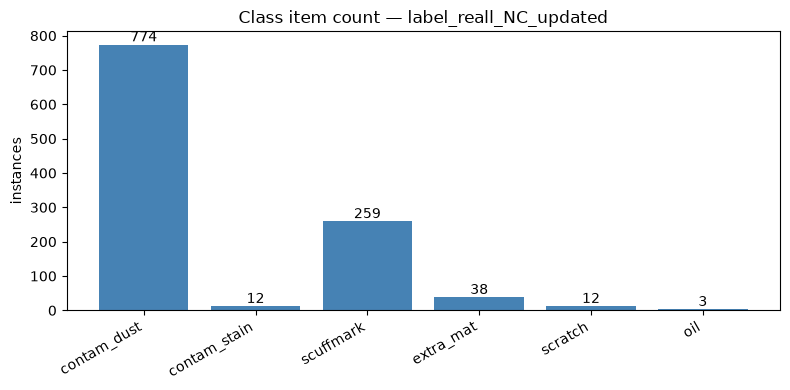

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df['class_name'], df['count'], color='steelblue')
ax.set_ylabel('instances')
ax.set_title(f'Class item count — {LABEL_DIR.name}')
for i, v in enumerate(df['count']):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Save results

Saves `class_counts.csv` and `.png` into `results/<source>/` next to this notebook.

In [ ]:
out_csv = RESULTS_DIR / 'class_counts.csv'
out_png = RESULTS_DIR / 'class_counts.png'
df.to_csv(out_csv, index=False)
fig.savefig(out_png, dpi=120)
print('saved:', out_csv)
print('saved:', out_png)

## 7. Per-day trend — parse date from filename

Day comes from the `_YYYYMMDD_` chunk in each filename. Builds a per-day × class instance-count matrix plus images/day.

Assumes the `mixall_0709` folder + `new_classes - Copy.txt` mapping (contam_dust, contam_stain, scuffmark, extra_mat, scratch, oil).

In [ ]:
import re
import numpy as np

DATE_RE = re.compile(r'_(\d{8})_')

day_class = {}          # {day: Counter{class_id: n_instances}}
day_imgs  = Counter()   # {day: n_label_files (= images)}
skipped = 0
for txt in LABEL_DIR.glob('*.txt'):
    m = DATE_RE.search(txt.name)
    if not m:
        skipped += 1
        continue
    day = m.group(1)
    day_imgs[day] += 1
    dc = day_class.setdefault(day, Counter())
    for ln in txt.read_text().splitlines():
        if ln.strip():
            dc[int(ln.split()[0])] += 1

days = sorted(day_imgs)
print(f'days: {len(days)}  ({days[0]} .. {days[-1]})   skipped(no date in name): {skipped}')
print(f'total images: {sum(day_imgs.values())}   total instances: {sum(sum(c.values()) for c in day_class.values())}')

days: 15  (20260618 .. 20260705)   skipped(no date in name): 0
total images: 368   total instances: 1098


## 8. Per-day table  (rows = day, cols = class, + images/total)

In [ ]:
ids  = sorted(set(id2name) | {c for dc in day_class.values() for c in dc})
cols = [id2name.get(c, f'UNKNOWN_{c}') for c in ids]

rows = []
for d in days:
    dc = day_class[d]
    row = {'day': d, 'images': day_imgs[d]}
    for cid, name in zip(ids, cols):
        row[name] = dc.get(cid, 0)
    row['total'] = sum(dc.values())
    rows.append(row)

day_df = pd.DataFrame(rows).set_index('day')
day_df

,images,contam_dust,contam_stain,scuffmark,extra_mat,scratch,oil,total
day,,,,,,,,
20260618,13,11,0,4,2,1,3,21
20260619,2,1,0,2,0,1,0,4
20260620,5,5,0,6,0,0,0,11
20260621,3,0,0,2,1,0,0,3
20260622,7,11,0,0,1,1,0,13
20260623,2,0,0,1,2,0,0,3
20260626,14,68,0,1,7,0,0,76
20260627,19,53,0,8,1,0,0,62
20260628,59,173,0,9,10,1,0,193


## 9. Charts — raw counts/day (stacked) + per-image rate/day (trend)

Raw bars show volume (confounded by how many images grabbed that day). Rate lines are volume-neutral — the real per-class trend.

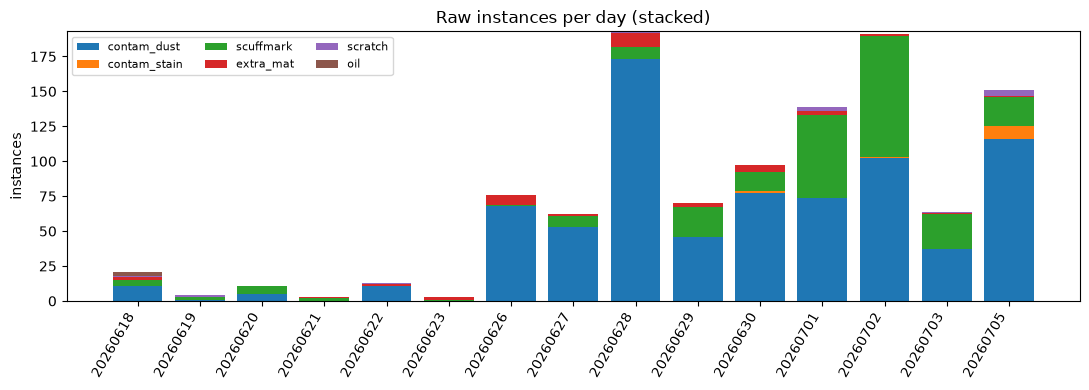

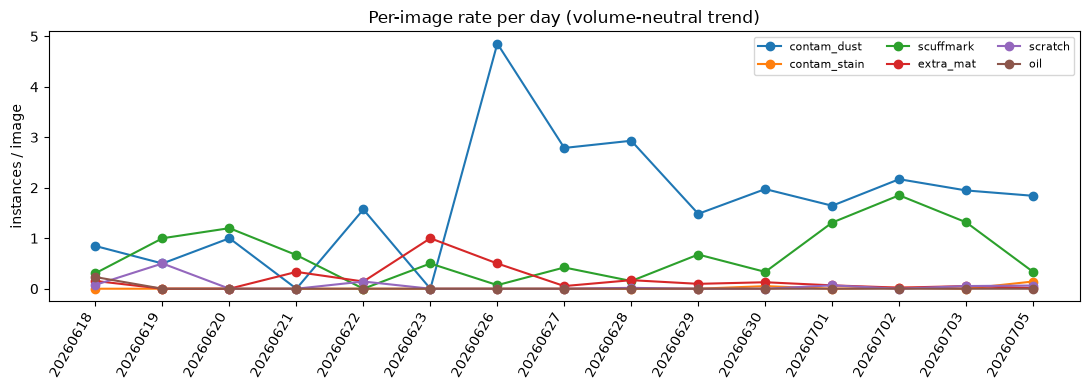

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(days))

# --- raw instances per day (stacked) ---
fig_raw, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(days))
for name in cols:
    vals = day_df[name].values
    ax.bar(x, vals, bottom=bottom, label=name)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(days, rotation=60, ha='right')
ax.set_ylabel('instances'); ax.set_title('Raw instances per day (stacked)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

# --- per-image rate per day (line) ---
fig_rate, ax = plt.subplots(figsize=(11, 4))
for name in cols:
    rate = day_df[name].values / day_df['images'].values
    ax.plot(x, rate, marker='o', label=name)
ax.set_xticks(x); ax.set_xticklabels(days, rotation=60, ha='right')
ax.set_ylabel('instances / image'); ax.set_title('Per-image rate per day (volume-neutral trend)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

## 10. Rate stability check

Forecast (§11) assumes each class's per-image rate is **stationary** (constant). This checks it: `rate_cv` = std/mean of the daily rate. Low cv → stable, forecast trustworthy. High cv (rare/noisy classes) → treat forecast as low-confidence.

In [ ]:
tot_imgs = int(day_df['images'].sum())
stab = []
for cid, name in zip(ids, cols):
    total = int(day_df[name].sum())
    day_rates = day_df[name].values / day_df['images'].values
    mean = day_rates.mean()
    cv = day_rates.std() / mean if mean else np.nan
    stab.append({'class': name, 'total': total,
                 'rate_overall': round(total / tot_imgs, 4),
                 'rate_day_mean': round(mean, 4),
                 'rate_cv': round(cv, 2) if np.isfinite(cv) else np.nan,
                 'stationary': 'ok' if (np.isfinite(cv) and cv < 0.5) else 'noisy/drift'})
stab_df = pd.DataFrame(stab)
stab_df

,class,total,rate_overall,rate_day_mean,rate_cv,stationary
0,contam_dust,774,2.1033,1.7039,0.70,noisy/drift
1,contam_stain,12,0.0326,0.0144,2.57,noisy/drift
2,scuffmark,259,0.7038,0.6761,0.78,noisy/drift
3,extra_mat,38,0.1033,0.1822,1.40,noisy/drift
4,scratch,12,0.0326,0.0613,2.03,noisy/drift
5,oil,3,0.0082,0.0154,3.74,noisy/drift


## 11. Forecast + sufficiency  (target = 200 instances/class)

Stationary-rate projection: `imgs_needed = (200 - current) / rate_per_img`, then `days_left = imgs_needed / avg_imgs_per_day`.

**Caveats:** avg images/day assumes future yield matches the past (it swings 19–95/day). Classes flagged `noisy/drift` in §10 (e.g. oil, extra_mat) — forecast is low confidence.

In [ ]:
TARGET = 200
avg_imgs_per_day = tot_imgs / len(days)

fc = []
for cid, name in zip(ids, cols):
    total = int(day_df[name].sum())
    rate  = total / tot_imgs                 # instances per image (stationary)
    if total >= TARGET:
        imgs_needed = days_left = 0
        status = 'MET'
    elif rate > 0:
        imgs_needed = (TARGET - total) / rate
        days_left   = imgs_needed / avg_imgs_per_day
        status = 'short'
    else:
        imgs_needed = days_left = np.inf
        status = 'no-data'
    fc.append({'class': name, 'current': total, 'target': TARGET,
               'rate_per_img': round(rate, 4),
               'imgs_needed': round(imgs_needed) if np.isfinite(imgs_needed) else np.inf,
               'days_left': round(days_left, 1) if np.isfinite(days_left) else np.inf,
               'status': status})

fc_df = pd.DataFrame(fc)
print(f'avg images/day = {avg_imgs_per_day:.1f}   (days_left uses this; real yield swings 19-95/day)')
fc_df

avg images/day = 24.5   (days_left uses this; real yield swings 19-95/day)


,class,current,target,rate_per_img,imgs_needed,days_left,status
0,contam_dust,774,200,2.1033,0,0.0,MET
1,contam_stain,12,200,0.0326,5765,235.0,short
2,scuffmark,259,200,0.7038,0,0.0,MET
3,extra_mat,38,200,0.1033,1569,63.9,short
4,scratch,12,200,0.0326,5765,235.0,short
5,oil,3,200,0.0082,24165,985.0,short


## 12. Save trend + forecast

Writes `perday_counts.csv`, `stability.csv`, `forecast.csv` (+ the two PNG charts) into `results/<source>/` next to this notebook. Rerun the whole notebook whenever new data lands.

In [ ]:
day_df.to_csv(RESULTS_DIR / 'perday_counts.csv')
stab_df.to_csv(RESULTS_DIR / 'stability.csv', index=False)
fc_df.to_csv(RESULTS_DIR / 'forecast.csv', index=False)
fig_raw.savefig(RESULTS_DIR / 'perday_raw.png', dpi=120, bbox_inches='tight')
fig_rate.savefig(RESULTS_DIR / 'perday_rate.png', dpi=120, bbox_inches='tight')
print('saved trend + forecast CSVs and PNGs to', RESULTS_DIR)